# 02 — Classification des consommateurs

**Prérequis** : avoir exécuté `01_clustering.ipynb` qui produit `RES2-6-9-labels.csv`.

Objectif : entraîner des modèles capables de prédire automatiquement le **cluster** d'un client (et donc son type RP/RS) à partir de ses features de consommation.

Le pipeline de features est **identique** à celui du notebook 01 pour garantir la cohérence.

### Flux de données
`RES2-6-9.csv` → features (même pipeline que NB01) → `RES2-6-9-labels.csv` (labels NB01) → modèles → évaluation

In [ ]:

# Imports

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Chargement des données et des labels issus du clustering

In [ ]:

# Chargement des données brutes + étiquettes du professeur

# Le clustering a été réalisé par le professeur et fourni dans
# RES2-6-9-labels.csv. Ce fichier est la SOURCE DE VÉRITÉ pour
# l'entraînement des classifieurs :
#   label_rs_rp : 0 = RP (Résidence Principale)   | 428 clients
#                 1 = RS (Résidence Secondaire)    |  72 clients
#
# Notre objectif : apprendre à prédire RP ou RS à partir des
# features de consommation calculées sur les données brutes.

BASE_DIR = Path(__file__).resolve().parent.parent

DATA_PATH = BASE_DIR / "Data" / "RES2-6-9.csv"
LABELS_PATH = BASE_DIR / "Data" / "RES2-6-9-labels.csv"   # référence prof — utilisée seulement à la fin

COL_PDL = 'pdl_id'
COL_DT  = 'horodate'
COL_PWR = 'puissance_w'

RANDOM_STATE = 42

raw = pd.read_csv(DATA_PATH)
raw.columns = [COL_PDL, COL_DT, COL_PWR]
raw[COL_DT] = pd.to_datetime(raw[COL_DT], utc=True, errors='coerce')
if raw[COL_DT].dt.tz is None:
    raw[COL_DT] = raw[COL_DT].dt.tz_localize('Europe/Paris')
else:
    raw[COL_DT] = raw[COL_DT].dt.tz_convert('Europe/Paris')
df = raw.dropna(subset=[COL_PDL, COL_DT, COL_PWR]).copy()
df[COL_PWR] = pd.to_numeric(df[COL_PWR], errors='coerce')
df = df.dropna(subset=[COL_PWR])
df['date']       = df[COL_DT].dt.date
df['dow']        = df[COL_DT].dt.dayofweek
df['is_weekend'] = df['dow'] >= 5
df['hh_index']   = df[COL_DT].dt.hour * 2 + df[COL_DT].dt.minute // 30

# Étiquettes RP/RS du professeur — variable cible de la classification
ref = pd.read_csv(LABELS_PATH)
ref.columns = [COL_PDL, 'label_rs_rp', 'cluster_ref']

print(f'Clients dans le CSV     : {df[COL_PDL].nunique()}')
print(f'Clients avec étiquette  : {ref[COL_PDL].nunique()}')
print(f'Distribution RP/RS :')
print(ref['label_rs_rp'].value_counts().rename({0:'RP (0)', 1:'RS (1)'}).to_string())


Clients dans le CSV     : 500
Clients avec étiquette  : 500
Distribution RP/RS :
label_rs_rp
RP (0)    428
RS (1)     72


## 2. Pipeline de features — identique au notebook 01

In [ ]:

# Reconstruction des mêmes 19 features que dans 01_clustering.ipynb

# IMPORTANT : le pipeline doit être rigoureusement identique au notebook 01.
# Si les features changent entre clustering et classification, le modèle
# apprend à prédire des labels calculés dans un espace différent -> incohérence.

# ── Agrégation journalière ──
daily = (
    df.assign(energy_kwh_step=df[COL_PWR] * 0.5)
    .groupby([COL_PDL, 'date'], as_index=False)
    .agg(
        daily_kwh    =('energy_kwh_step', 'sum'),
        daily_mean_kw=(COL_PWR,           'mean'),
        daily_max_kw =(COL_PWR,           'max'),
        n_steps      =(COL_PWR,           'size'),
    )
)

# ── Seuil d'activité par client ──
def q20_positive(s):
    """Renvoie le 20e centile des valeurs strictement positives d'une série.

    Sert de seuil d'activité propre à chaque client : un jour est jugé
    « actif » si sa consommation atteint au moins ce centile. Les valeurs
    nulles sont écartées afin que le seuil reflète les jours réellement
    consommateurs et non les périodes d'inoccupation.
    """
    s = s[s > 0]
    return s.quantile(0.2) if len(s) > 0 else np.nan

daily['th_pdl']       = daily.groupby(COL_PDL)['daily_kwh'].transform(q20_positive)
daily['is_active_day']= (daily['daily_kwh'] >= daily['th_pdl']).fillna(False)

print('Agrégation journalière OK')

Agrégation journalière OK


In [ ]:

# Construction des features de consommation (suite du notebook 01)

# Quatre groupes de features décrivant le comportement de chaque client :
#   1. Activité globale            3. Pattern hebdomadaire (semaine / week-end)
#   2. Séquences actives et gaps   4. Ratios saisonniers (hiver / été / mi-saison)

# ── Feature 1 : Activité globale ──
activity = (
    daily.groupby(COL_PDL, as_index=False)
    .agg(
        n_days         =(COL_PDL,         'size'),
        n_active_days  =('is_active_day', 'sum'),
        active_day_rate=('is_active_day', 'mean'),
        mean_daily_kwh =('daily_kwh',     'mean'),
        p95_daily_kwh  =('daily_kwh',     lambda s: s.quantile(0.95)),
        cv_daily_kwh   =('daily_kwh',     lambda s: s.std() / s.mean() if s.mean() != 0 else np.nan),
    )
)

# ── Feature 2 : Séquences actives (runs) et lacunes (gaps) ──
def runs_and_gaps(active_series):
    """Mesure l'alternance entre jours actifs et jours inactifs d'un client.

    Parcourt la série booléenne d'activité et calcule :
      - les « runs » : longueurs des séquences de jours actifs consécutifs ;
      - les « gaps » : longueurs des séquences de jours inactifs consécutifs.

    Ces statistiques séparent un RP (activité quasi continue, gaps courts)
    d'un RS (longues périodes d'inoccupation, donc gaps longs).

    Renvoie une Series : n_runs, mean_run_len, max_run_len,
    mean_gap_len, max_gap_len.
    """
    runs, gaps = [], []
    run, gap   = 0, 0
    for v in active_series.astype(bool):
        if v:
            run += 1
            if gap > 0: gaps.append(gap); gap = 0
        else:
            gap += 1
            if run > 0: runs.append(run); run = 0
    if run > 0: runs.append(run)
    if gap > 0: gaps.append(gap)
    return pd.Series({
        'n_runs'      : len(runs),
        'mean_run_len': float(np.mean(runs)) if runs else 0.0,
        'max_run_len' : float(np.max(runs))  if runs else 0.0,
        'mean_gap_len': float(np.mean(gaps)) if gaps else 0.0,
        'max_gap_len' : float(np.max(gaps))  if gaps else 0.0,
    })

runs_stats = (
    daily.sort_values([COL_PDL, 'date'])
    .groupby(COL_PDL)['is_active_day']
    .apply(runs_and_gaps)
    .unstack()
    .reset_index()
)

# ── Feature 3 : Pattern hebdomadaire ──
daily['date_ts']    = pd.to_datetime(daily['date'])
daily['dow']        = daily['date_ts'].dt.dayofweek
daily['is_weekend'] = daily['dow'] >= 5

week_pattern = (
    daily
    .groupby([COL_PDL, 'is_weekend'], as_index=False)
    .agg(active_rate=('is_active_day', 'mean'), mean_kwh=('daily_kwh', 'mean'))
    .pivot(index=COL_PDL, columns='is_weekend')
)
week_pattern.columns = [
    f"{stat}_{'weekend' if is_we else 'weekday'}" for stat, is_we in week_pattern.columns
]
week_pattern = week_pattern.reset_index()

# ── Feature 4 : Ratios saisonniers ──
def season_from_month(m):
    """Associe un mois (1-12) à une saison simplifiée : hiver, été ou mi-saison."""
    if m in (12, 1, 2): return 'winter'
    if m in (6, 7, 8):  return 'summer'
    return 'mid'

daily2          = daily.copy()
daily2['month'] = daily2['date_ts'].dt.month
daily2['season']= daily2['month'].map(season_from_month)

season_stats = (
    daily2.groupby([COL_PDL, 'season'], as_index=False)
    .agg(mean_daily_kwh=('daily_kwh', 'mean'))
    .pivot(index=COL_PDL, columns='season', values='mean_daily_kwh')
    .reset_index()
)
for c in ['winter', 'summer', 'mid']:
    if c not in season_stats.columns: season_stats[c] = 0.0

global_mean  = daily2.groupby(COL_PDL, as_index=False).agg(mean_daily_kwh_global=('daily_kwh','mean'))
season_stats = season_stats.merge(global_mean, on=COL_PDL, how='left', validate='one_to_one')
eps = 1e-9
season_stats['r_global'] = 1.0
season_stats['r_mid']    = season_stats['mid']    / (season_stats['mean_daily_kwh_global'] + eps)
season_stats['r_summer'] = season_stats['summer'] / (season_stats['mean_daily_kwh_global'] + eps)
season_stats['r_winter'] = season_stats['winter'] / (season_stats['mean_daily_kwh_global'] + eps)
season_stats = season_stats[[COL_PDL, 'r_global', 'r_mid', 'r_summer', 'r_winter']]

print('Features construites OK')

Features construites OK


In [5]:
# ── Assemblage + features dérivées (identique au notebook 01) ──
features_pdl = (
    activity
    .merge(runs_stats,   on=COL_PDL, how='left', validate='one_to_one')
    .merge(week_pattern, on=COL_PDL, how='left', validate='one_to_one')
    .merge(season_stats, on=COL_PDL, how='left', validate='one_to_one')
)

# Deux features dérivées résumant la sensibilité saisonnière du client :
#   seasonality_amp     : amplitude entre la saison la plus et la moins consommatrice
#   winter_minus_summer : écart hiver - été (positif = chauffage électrique marqué)
features_pdl['seasonality_amp']     = (
    features_pdl[['r_mid','r_summer','r_winter']].max(axis=1) -
    features_pdl[['r_mid','r_summer','r_winter']].min(axis=1)
)
features_pdl['winter_minus_summer'] = features_pdl['r_winter'] - features_pdl['r_summer']

# ── Fusion avec les étiquettes RP/RS du professeur (variable cible) ──
features_pdl = features_pdl.merge(ref[[COL_PDL, 'label_rs_rp']], on=COL_PDL, how='inner')

assert features_pdl[COL_PDL].is_unique
print(f'Dataset final : {len(features_pdl)} clients')
print(f'RP : {sum(features_pdl["label_rs_rp"]==0)} | RS : {sum(features_pdl["label_rs_rp"]==1)}')


Dataset final : 500 clients
RP : 428 | RS : 72


## 3. Préparation de X et y

In [ ]:

# Définition des features et de la variable cible

# Features : les mêmes 19 que dans le notebook 01 (clustering).
# Target y : label_rs_rp fourni par le professeur (0=RP, 1=RS).
# Problème : classification binaire (2 classes, déséquilibrées : 428 RP vs 72 RS).

FEATURE_COLS = [
    'active_day_rate', 'n_runs', 'mean_run_len', 'max_run_len',
    'mean_gap_len', 'max_gap_len',
    'mean_daily_kwh', 'p95_daily_kwh', 'cv_daily_kwh',
    'active_rate_weekday', 'active_rate_weekend',
    'mean_kwh_weekday', 'mean_kwh_weekend',
    'winter_minus_summer', 'seasonality_amp',
    'r_global', 'r_mid', 'r_summer', 'r_winter',
]

X = features_pdl[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0.0).values
y = features_pdl['label_rs_rp'].values   # 0 = RP, 1 = RS

print(f'X : {X.shape}  ({len(FEATURE_COLS)} features, {X.shape[0]} clients)')
print(f'y : 2 classes  (RP={sum(y==0)}, RS={sum(y==1)})')
print(f'Déséquilibre : RP={sum(y==0)/len(y)*100:.1f}%  RS={sum(y==1)/len(y)*100:.1f}%')


X : (500, 19)  (19 features, 500 clients)
y : 2 classes  (RP=428, RS=72)
Déséquilibre : RP=85.6%  RS=14.4%


## 4. Split train / test et normalisation

In [ ]:

# Séparation train/test et standardisation

# stratify=y : maintient la proportion RP/RS dans train et test (important car déséquilibré)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Le scaler est fit UNIQUEMENT sur le train pour éviter le data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} clients | Test : {X_test.shape[0]} clients')
print(f'Train RP/RS : {sum(y_train==0)}/{sum(y_train==1)} | Test RP/RS : {sum(y_test==0)}/{sum(y_test==1)}')

Train : 400 clients | Test : 100 clients
Train RP/RS : 342/58 | Test RP/RS : 86/14


## 5. Optimisation des hyperparamètres par validation croisée

In [ ]:

# Configuration commune à toutes les recherches

# - StratifiedKFold : maintient la proportion RP/RS dans chaque fold
# - scoring='f1_macro' : moyenne non pondérée F1-RP et F1-RS
#   → pénalise également les erreurs sur la classe majoritaire (RP)
#   et sur la classe minoritaire (RS), adapté au déséquilibre 85/15.
# - class_weight='balanced' : pondère automatiquement les classes
#   inversement à leur fréquence → évite que le modèle prédise toujours RP.

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
import time

CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING      = 'f1_macro'

best_models  = {}   # stocke {nom: clf_optimisé} pour la comparaison finale
search_logs  = {}   # stocke les résultats de chaque recherche

print("Configuration CV : StratifiedKFold(5), scoring=f1_macro")
print(f"Train : {X_train.shape[0]} clients  |  Test : {X_test.shape[0]} clients")


Configuration CV : StratifiedKFold(5), scoring=f1_macro
Train : 400 clients  |  Test : 100 clients


### 5.1 Régression Logistique — GridSearchCV sur C

In [ ]:

# Régression Logistique

# Hyperparamètre clé : C (inverse de la régularisation L2).
#   C petit → forte régularisation → modèle simple, risque de sous-ajustement.
#   C grand → faible régularisation → modèle flexible, risque de sur-ajustement.
# On explore 6 valeurs sur une échelle logarithmique.

from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
}

lr_base = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=RANDOM_STATE,
)

t0 = time.time()
gs_lr = GridSearchCV(
    lr_base,
    param_grid_lr,
    cv=CV_STRATEGY,
    scoring=SCORING,
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)
gs_lr.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"Meilleurs hyperparamètres LR : {gs_lr.best_params_}")
print(f"F1-macro CV (train)          : {gs_lr.best_score_:.4f}")
print(f"Durée recherche              : {elapsed:.1f} s")

# Résultats détaillés
lr_cv_results = pd.DataFrame(gs_lr.cv_results_)[['param_C','mean_test_score','std_test_score']]
lr_cv_results.columns = ['C', 'F1-macro (CV)', 'Std']
lr_cv_results = lr_cv_results.sort_values('F1-macro (CV)', ascending=False)
print("\nGrille complète :")
print(lr_cv_results.to_string(index=False))

best_models['Régression Logistique'] = gs_lr.best_estimator_
search_logs['Régression Logistique'] = gs_lr


Meilleurs hyperparamètres LR : {'C': 1}
F1-macro CV (train)          : 0.9658
Durée recherche              : 3.8 s

Grille complète :
      C  F1-macro (CV)      Std
  1.000       0.965847 0.019691
  0.001       0.964456 0.034439
 10.000       0.955707 0.009452
  0.010       0.952863 0.032706
  0.100       0.948445 0.034123
100.000       0.945903 0.023801


### 5.2 Random Forest — RandomizedSearchCV

In [ ]:

# Random Forest

# Hyperparamètres clés :
#   n_estimators   : nombre d'arbres (plus = plus stable, mais plus lent).
#   max_depth      : profondeur max de chaque arbre (None = sans limite).
#   min_samples_leaf: nombre min d'exemples par feuille (régularisation).
#   max_features   : nb de features testées à chaque split ('sqrt' = racine carrée).
#
# RandomizedSearchCV : explore aléatoirement l'espace (n_iter combinaisons).
# Plus rapide que GridSearchCV quand l'espace est grand.

from sklearn.ensemble import RandomForestClassifier

param_dist_rf = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features'    : ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.time()
rs_rf = RandomizedSearchCV(
    rf_base,
    param_dist_rf,
    n_iter=30,              # 30 combinaisons aléatoires
    cv=CV_STRATEGY,
    scoring=SCORING,
    n_jobs=-1,
    verbose=0,
    random_state=RANDOM_STATE,
    return_train_score=True,
)
rs_rf.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"Meilleurs hyperparamètres RF : {rs_rf.best_params_}")
print(f"F1-macro CV (train)          : {rs_rf.best_score_:.4f}")
print(f"Durée recherche              : {elapsed:.1f} s")

best_models['Random Forest'] = rs_rf.best_estimator_
search_logs['Random Forest'] = rs_rf


Meilleurs hyperparamètres RF : {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
F1-macro CV (train)          : 0.9738
Durée recherche              : 6.9 s


### 5.3 SVM (kernel RBF) — GridSearchCV sur C et gamma

Meilleurs hyperparamètres SVM : {'C': 10, 'gamma': 0.01}
F1-macro CV (train)           : 0.9750
Durée recherche               : 0.2 s


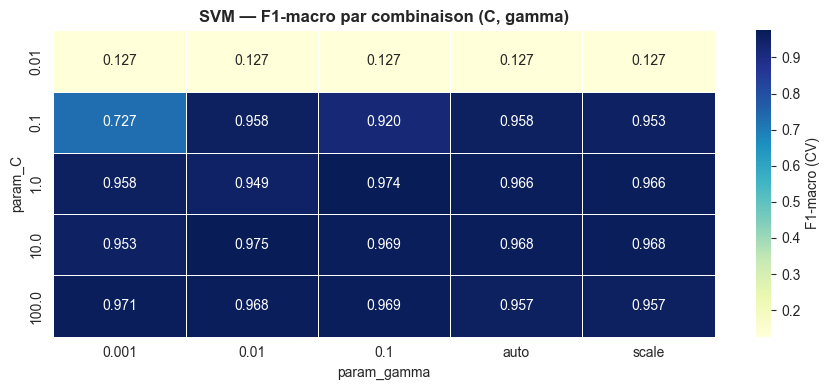

In [ ]:

# SVM avec kernel RBF

# Hyperparamètres clés :
#   C     : marge de tolérance aux erreurs de classification.
#            C petit → marge large, moins de sur-ajustement.
#            C grand → marge étroite, mieux sur le train, risque sur-ajustement.
#   gamma : largeur du kernel RBF (influence du rayon de chaque point).
#            'scale' = 1 / (n_features × Var(X)) — souvent bon point de départ.
#            gamma grand → frontière très localisée (sur-ajustement).
#
# Note : SVM est sensible à la normalisation → X_train est déjà standardisé.

from sklearn.svm import SVC

param_grid_svm = {
    'C'    : [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
}

svm_base = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE,
)

t0 = time.time()
gs_svm = GridSearchCV(
    svm_base,
    param_grid_svm,
    cv=CV_STRATEGY,
    scoring=SCORING,
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)
gs_svm.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"Meilleurs hyperparamètres SVM : {gs_svm.best_params_}")
print(f"F1-macro CV (train)           : {gs_svm.best_score_:.4f}")
print(f"Durée recherche               : {elapsed:.1f} s")

# Heatmap C × gamma
svm_results = pd.DataFrame(gs_svm.cv_results_)
pivot_svm = svm_results.pivot_table(
    index='param_C', columns='param_gamma', values='mean_test_score'
)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(9, 4))
sns.heatmap(pivot_svm.astype(float), annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'F1-macro (CV)'})
plt.title('SVM — F1-macro par combinaison (C, gamma)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_svm_grid.png', dpi=150, bbox_inches='tight')
plt.show()

best_models['SVM (RBF)'] = gs_svm.best_estimator_
search_logs['SVM (RBF)'] = gs_svm


### 5.4 MLP — RandomizedSearchCV sur l'architecture et la régularisation

In [ ]:

# MLP (réseau de neurones multi-couches)

# Hyperparamètres clés :
#   hidden_layer_sizes : architecture (nombre et taille des couches cachées).
#   alpha              : régularisation L2 (évite le sur-ajustement).
#   learning_rate_init : pas d'apprentissage initial de l'optimiseur Adam.
#
# RandomizedSearchCV : l'espace combinatoire est grand (5 × 4 × 3 = 60),
# on en explore 20 aléatoirement pour un bon compromis vitesse/qualité.

from sklearn.neural_network import MLPClassifier

param_dist_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'alpha'             : [1e-4, 1e-3, 1e-2, 1e-1],
    'learning_rate_init': [1e-3, 5e-3, 1e-2],
}

mlp_base = MLPClassifier(
    max_iter=500,
    early_stopping=True,     # arrêt si val-loss stagne → évite sur-ajustement
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
)

t0 = time.time()
rs_mlp = RandomizedSearchCV(
    mlp_base,
    param_dist_mlp,
    n_iter=20,
    cv=CV_STRATEGY,
    scoring=SCORING,
    n_jobs=-1,
    verbose=0,
    random_state=RANDOM_STATE,
    return_train_score=True,
)
rs_mlp.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"Meilleurs hyperparamètres MLP : {rs_mlp.best_params_}")
print(f"F1-macro CV (train)           : {rs_mlp.best_score_:.4f}")
print(f"Durée recherche               : {elapsed:.1f} s")

best_models['MLP'] = rs_mlp.best_estimator_
search_logs['MLP'] = rs_mlp


Meilleurs hyperparamètres MLP : {'learning_rate_init': 0.005, 'hidden_layer_sizes': (64,), 'alpha': 0.01}
F1-macro CV (train)           : 0.9644
Durée recherche               : 0.4 s


## 6. Comparaison finale des modèles optimisés

In [ ]:

# Évaluation sur le jeu de TEST (jamais vu pendant l'optimisation)

from sklearn.metrics import classification_report, f1_score, confusion_matrix

final_results = {}

for name, clf in best_models.items():
    y_pred = clf.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=['RP','RS'],
                                    output_dict=True)
    final_results[name] = {
        'model' : clf,
        'y_pred': y_pred,
        'f1_rs' : report['RS']['f1-score'],
        'f1_mac': f1_score(y_test, y_pred, average='macro'),
        'cv_f1' : search_logs[name].best_score_,
        'acc'   : report['accuracy'],
        'best_params': search_logs[name].best_params_,
    }

# Tableau récapitulatif
summary_rows = []
for name, r in final_results.items():
    row = {'Modèle': name, 'Accuracy': f"{r['acc']:.3f}",
           'F1-RS': f"{r['f1_rs']:.3f}", 'F1-macro (test)': f"{r['f1_mac']:.3f}",
           'F1-macro (CV)': f"{r['cv_f1']:.3f}"}
    row.update({f'HP: {k}': v for k, v in r['best_params'].items()})
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
print(summary[['Modèle','Accuracy','F1-RS','F1-macro (test)','F1-macro (CV)']].to_string(index=False))

best_name = max(final_results, key=lambda n: final_results[n]['f1_mac'])
print(f"\n→ Meilleur modèle : {best_name}  "
      f"(F1-macro test={final_results[best_name]['f1_mac']:.4f})")
print(f"  Hyperparamètres  : {final_results[best_name]['best_params']}")


               Modèle Accuracy F1-RS F1-macro (test) F1-macro (CV)
Régression Logistique    0.980 0.933           0.961         0.966
        Random Forest    0.980 0.929           0.958         0.974
            SVM (RBF)    0.990 0.966           0.980         0.975
                  MLP    0.980 0.933           0.961         0.964

→ Meilleur modèle : SVM (RBF)  (F1-macro test=0.9798)
  Hyperparamètres  : {'C': 10, 'gamma': 0.01}


## 7. Matrices de confusion

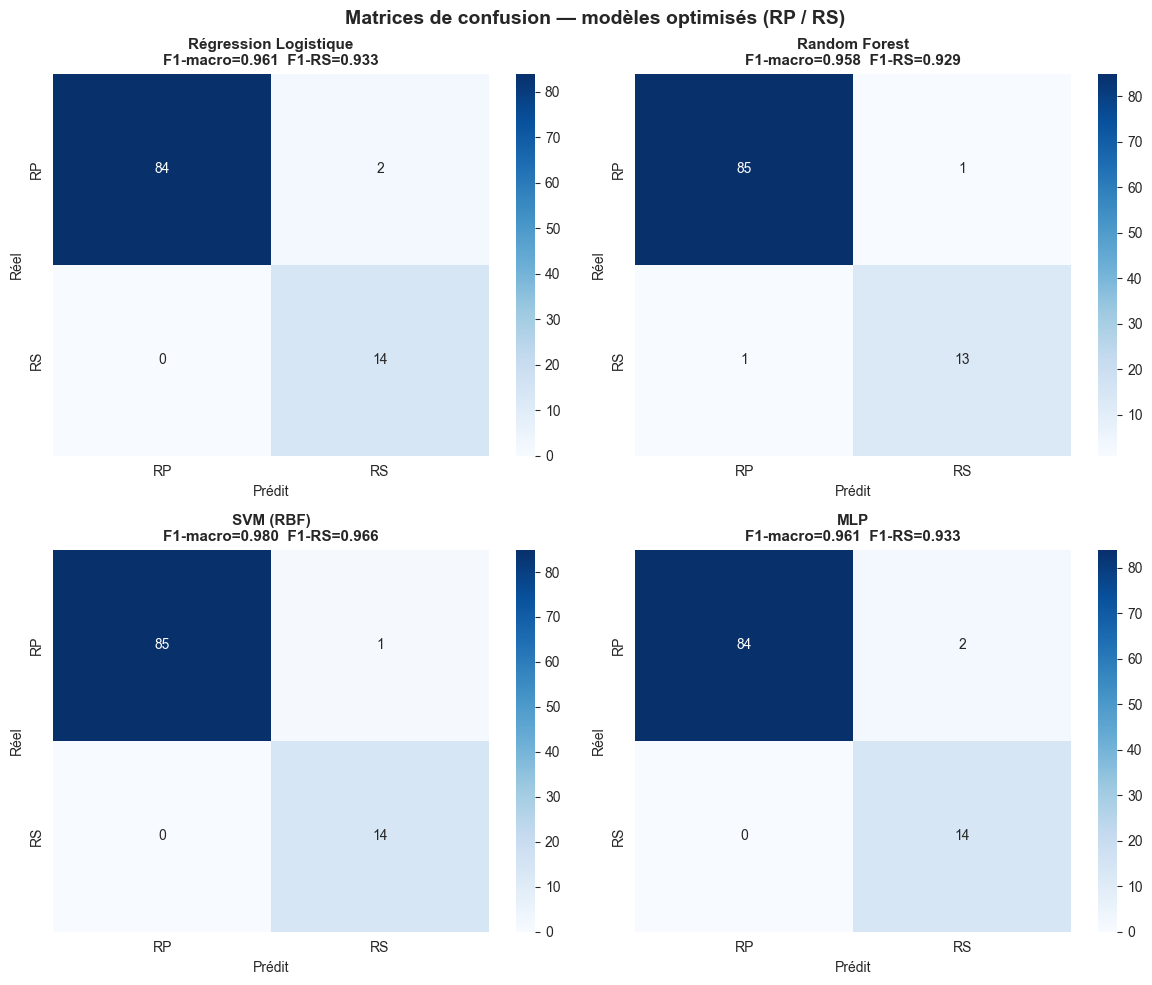

In [ ]:

# Matrices de confusion — modèles optimisés

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, r) in zip(axes.flatten(), final_results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['RP','RS'], yticklabels=['RP','RS'])
    ax.set_title(f"{name}\nF1-macro={r['f1_mac']:.3f}  F1-RS={r['f1_rs']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — modèles optimisés (RP / RS)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Importance des features (Random Forest optimisé)

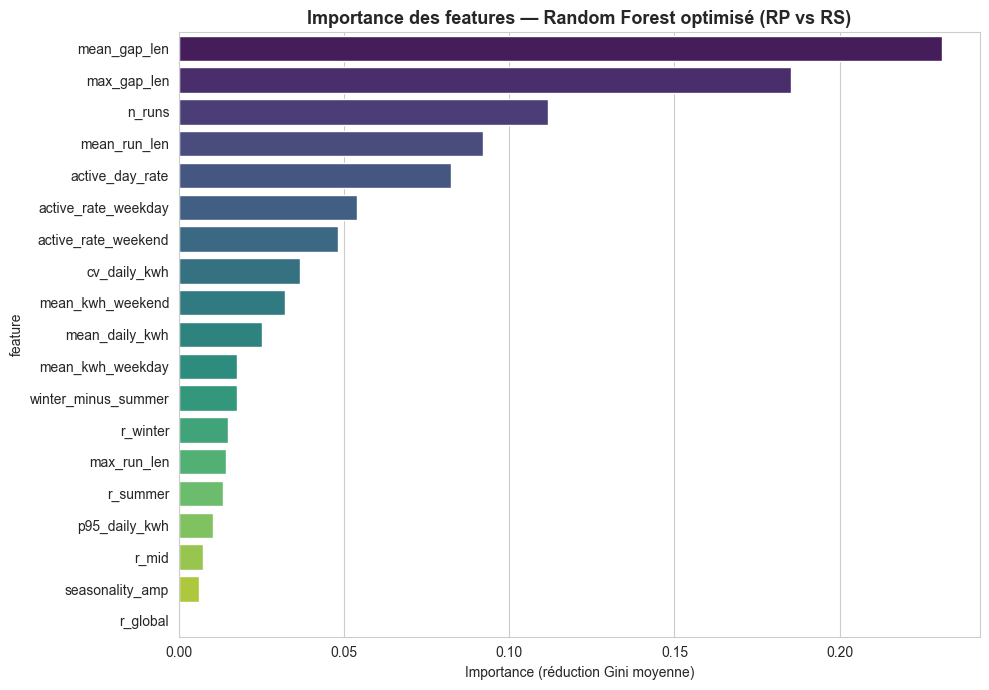

Top 10 features :
            feature  importance
       mean_gap_len    0.230925
        max_gap_len    0.185267
             n_runs    0.111744
       mean_run_len    0.092096
    active_day_rate    0.082320
active_rate_weekday    0.054002
active_rate_weekend    0.048067
       cv_daily_kwh    0.036782
   mean_kwh_weekend    0.032178
     mean_daily_kwh    0.025082


In [ ]:

# Importance des features sur le RF avec les hyperparamètres optimaux

rf_opt = best_models['Random Forest']
imp_df = (
    pd.DataFrame({'feature': FEATURE_COLS, 'importance': rf_opt.feature_importances_})
    .sort_values('importance', ascending=False)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title('Importance des features — Random Forest optimisé (RP vs RS)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance (réduction Gini moyenne)')
plt.tight_layout()
plt.savefig('fig_05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features :')
print(imp_df.head(10).to_string(index=False))


## 9. Rapport détaillé et visualisation PCA

Meilleur modèle : SVM (RBF)
Hyperparamètres : {'C': 10, 'gamma': 0.01}
              precision    recall  f1-score   support

          RP       1.00      0.99      0.99        86
          RS       0.93      1.00      0.97        14

    accuracy                           0.99       100
   macro avg       0.97      0.99      0.98       100
weighted avg       0.99      0.99      0.99       100



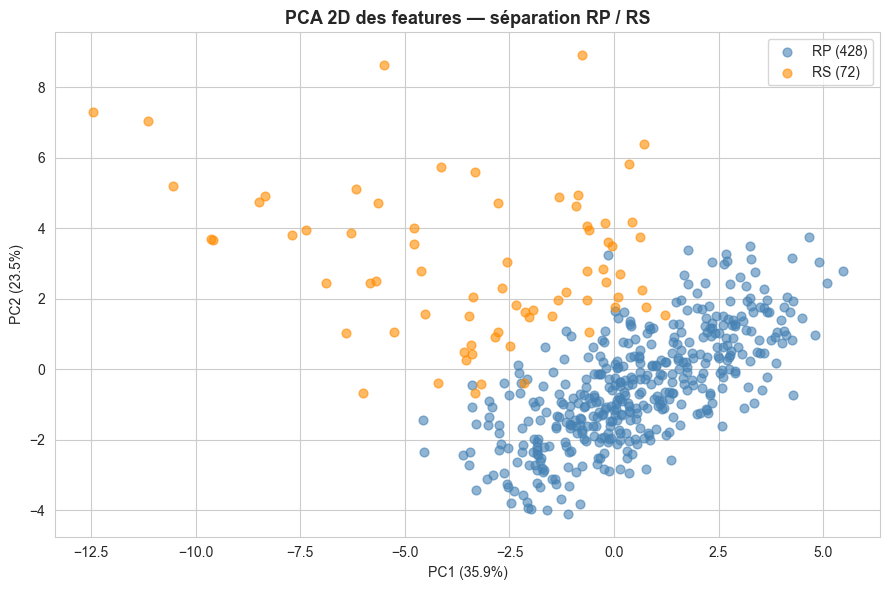

In [ ]:

# Rapport de classification — meilleur modèle optimisé

from sklearn.decomposition import PCA

print(f"Meilleur modèle : {best_name}")
print(f"Hyperparamètres : {final_results[best_name]['best_params']}")
print('=' * 55)
print(classification_report(y_test, final_results[best_name]['y_pred'],
                              target_names=['RP','RS']))

# Visualisation PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_all_scaled = scaler.transform(X)
Z = pca.fit_transform(X_all_scaled)

plt.figure(figsize=(9, 6))
for label, name, color in [(0,'RP','steelblue'), (1,'RS','darkorange')]:
    mask = y == label
    plt.scatter(Z[mask, 0], Z[mask, 1], label=f'{name} ({mask.sum()})',
                alpha=0.6, s=40, color=color)
plt.title('PCA 2D des features — séparation RP / RS', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(); plt.tight_layout()
plt.savefig('fig_06_pca_rs_rp.png', dpi=150, bbox_inches='tight')
plt.show()
